In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [13]:
df = pd.read_excel("/content/Sales_Prediction_Dataset.xlsx")
df.head()

,Date,Sales
0,2025-01-01,103
1,2025-01-02,103
2,2025-01-03,112
3,2025-01-04,123
4,2025-01-05,130


In [14]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.capitalize()
df.columns

Index(['Date', 'Sales'], dtype='object')

In [15]:
df['Date'] = pd.to_datetime(df['Date'])
df['Days'] = (df['Date'] - df['Date'].min()).dt.days

In [16]:
X = df[['Days']]
y = df['Sales']

In [17]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [18]:
future_days = np.arange(X.max()[0]+1, X.max()[0]+30).reshape(-1,1)
future_pred = model.predict(future_days)

/tmp/ipykernel_6559/3479239995.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  future_days = np.arange(X.max()[0]+1, X.max()[0]+30).reshape(-1,1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


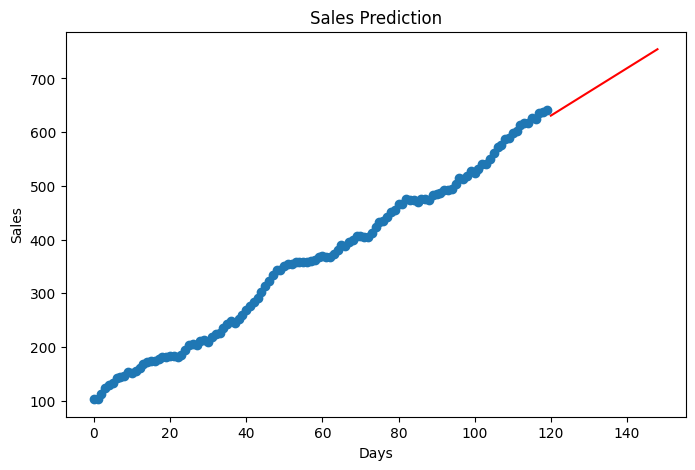

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(X, y)
plt.plot(future_days, future_pred, color='red')
plt.xlabel("Days")
plt.ylabel("Sales")
plt.title("Sales Prediction")
plt.show()

In [20]:
print("Accuracy:", model.score(X,y))

Accuracy: 0.9928591195199268
